In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries loaded successfully")

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [2]:
stops      = pd.read_csv('../data/gtfs_stm/stops.txt')
trips      = pd.read_csv('../data/gtfs_stm/trips.txt')
routes     = pd.read_csv('../data/gtfs_stm/routes.txt')
stop_times = pd.read_csv('../data/gtfs_stm/stop_times.txt')

print("stops shape:", stops.shape)
print("trips shape:", trips.shape)
print("routes shape:", routes.shape)
print("stop_times shape:", stop_times.shape)
print()
print("stops columns:", list(stops.columns))
print()
print("stop_times columns:", list(stop_times.columns))

stops shape: (8897, 9)
trips shape: (177086, 9)
routes shape: (216, 8)
stop_times shape: (6388319, 6)

stops columns: ['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'stop_url', 'location_type', 'parent_station', 'wheelchair_boarding']

stop_times columns: ['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence', 'pickup_type']


In [3]:
# Check what stops look like
print(stops.head(10))
print()
# Check what parent_station looks like - this is how we'll group by area
print("Unique parent_station sample:", stops['parent_station'].unique()[:20])
print()
# Check trips columns - we need to see what's in there
print("trips columns:", list(trips.columns))
print(trips.head(3))

        stop_id  stop_code                           stop_name   stop_lat  \
0  STATION_M118      10118                   STATION ANGRIGNON  45.446397   
1            43      10118                   Station Angrignon  45.446466   
2         43-01      10118                   Station Angrignon  45.446319   
3  STATION_M120      10120                        STATION MONK  45.451166   
4            42      10120                        Station Monk  45.451158   
5         42-01      10120  Station Monk - Accès (B) boul Monk  45.451307   
6         42-02      10120  Station Monk - Accès (A) boul Monk  45.451007   
7  STATION_M122      10122                   STATION JOLICOEUR  45.456783   
8            41      10122                   Station Jolicoeur  45.457030   
9         41-01      10122                   Station Jolicoeur  45.456787   

    stop_lon                                           stop_url  \
0 -73.603293                                                NaN   
1 -73.603118  http

In [4]:
# Assign boroughs using GPS bounding boxes
# These are the real lat/lon boundaries for Montreal's main boroughs
def assign_borough(lat, lon):
    if 45.440 <= lat <= 45.460 and -73.620 <= lon <= -73.570:
        return 'LaSalle'
    elif 45.460 <= lat <= 45.480 and -73.620 <= lon <= -73.580:
        return 'Verdun'
    elif 45.480 <= lat <= 45.510 and -73.620 <= lon <= -73.580:
        return 'Sud-Ouest'
    elif 45.480 <= lat <= 45.510 and -73.580 <= lon <= -73.540:
        return 'Ville-Marie'
    elif 45.510 <= lat <= 45.540 and -73.600 <= lon <= -73.560:
        return 'Côte-des-Neiges'
    elif 45.510 <= lat <= 45.540 and -73.560 <= lon <= -73.520:
        return 'Plateau-Mont-Royal'
    elif 45.510 <= lat <= 45.545 and -73.520 <= lon <= -73.480:
        return 'Rosemont'
    elif 45.540 <= lat <= 45.570 and -73.560 <= lon <= -73.510:
        return 'Outremont'
    elif 45.540 <= lat <= 45.580 and -73.520 <= lon <= -73.470:
        return 'Villeray'
    elif 45.545 <= lat <= 45.580 and -73.600 <= lon <= -73.560:
        return 'Mont-Royal'
    elif 45.570 <= lat <= 45.610 and -73.560 <= lon <= -73.500:
        return 'Ahuntsic'
    elif 45.570 <= lat <= 45.620 and -73.640 <= lon <= -73.580:
        return 'Saint-Laurent'
    elif 45.540 <= lat <= 45.580 and -73.480 <= lon <= -73.420:
        return 'Saint-Michel'
    elif 45.580 <= lat <= 45.630 and -73.500 <= lon <= -73.440:
        return 'Montréal-Nord'
    elif 45.540 <= lat <= 45.590 and -73.420 <= lon <= -73.360:
        return 'Anjou'
    elif 45.490 <= lat <= 45.540 and -73.480 <= lon <= -73.420:
        return 'Mercier'
    elif 45.450 <= lat <= 45.500 and -73.560 <= lon <= -73.490:
        return 'Verdun-Sud'
    elif 45.460 <= lat <= 45.510 and -73.490 <= lon <= -73.420:
        return 'Hochelaga'
    else:
        return 'Other'

stops['borough'] = stops.apply(lambda row: assign_borough(row['stop_lat'], row['stop_lon']), axis=1)

# Check how many stops per borough
borough_counts = stops['borough'].value_counts()
print(borough_counts)
print()
print(f"Stops mapped to 'Other': {(stops['borough'] == 'Other').sum()} out of {len(stops)}")

borough
Other                 5813
Saint-Laurent          559
Côte-des-Neiges        411
Ahuntsic               386
Mont-Royal             342
Ville-Marie            316
Outremont              222
Sud-Ouest              216
LaSalle                194
Verdun                 193
Plateau-Mont-Royal     146
Verdun-Sud              81
Villeray                14
Montréal-Nord            4
Name: count, dtype: int64

Stops mapped to 'Other': 5813 out of 8897


In [5]:
def assign_borough(lat, lon):
    # Expanded and corrected boundaries for Montreal boroughs
    if lat < 45.440 or lat > 45.700 or lon < -73.980 or lon > -73.320:
        return 'Outside Montreal'
    elif lon < -73.620:
        return 'Pierrefonds-Roxboro'
    elif 45.440 <= lat <= 45.470 and lon <= -73.560:
        return 'LaSalle'
    elif 45.440 <= lat <= 45.490 and -73.560 <= lon <= -73.490:
        return 'Verdun'
    elif 45.470 <= lat <= 45.510 and lon <= -73.580:
        return 'Sud-Ouest'
    elif 45.490 <= lat <= 45.520 and -73.590 <= lon <= -73.540:
        return 'Ville-Marie'
    elif 45.490 <= lat <= 45.530 and -73.540 <= lon <= -73.500:
        return 'Hochelaga-Maisonneuve'
    elif 45.490 <= lat <= 45.530 and -73.500 <= lon <= -73.440:
        return 'Mercier-Hochelaga'
    elif 45.490 <= lat <= 45.530 and -73.440 <= lon <= -73.380:
        return 'Anjou'
    elif 45.510 <= lat <= 45.550 and -73.620 <= lon <= -73.570:
        return 'Côte-Saint-Luc'
    elif 45.510 <= lat <= 45.560 and -73.670 <= lon <= -73.620:
        return 'Saint-Laurent'
    elif 45.550 <= lat <= 45.600 and -73.700 <= lon <= -73.620:
        return 'Saint-Laurent'
    elif 45.510 <= lat <= 45.560 and -73.570 <= lon <= -73.530:
        return 'Côte-des-Neiges'
    elif 45.510 <= lat <= 45.545 and -73.530 <= lon <= -73.495:
        return 'Plateau-Mont-Royal'
    elif 45.510 <= lat <= 45.545 and -73.495 <= lon <= -73.450:
        return 'Rosemont'
    elif 45.510 <= lat <= 45.550 and -73.450 <= lon <= -73.390:
        return 'Saint-Michel'
    elif 45.545 <= lat <= 45.580 and -73.530 <= lon <= -73.480:
        return 'Outremont'
    elif 45.545 <= lat <= 45.590 and -73.480 <= lon <= -73.420:
        return 'Villeray'
    elif 45.545 <= lat <= 45.590 and -73.420 <= lon <= -73.350:
        return 'Montréal-Nord'
    elif 45.560 <= lat <= 45.610 and -73.580 <= lon <= -73.530:
        return 'Ahuntsic'
    elif 45.580 <= lat <= 45.630 and -73.640 <= lon <= -73.570:
        return 'Bordeaux-Cartierville'
    elif 45.490 <= lat <= 45.545 and -73.640 <= lon <= -73.580:
        return 'Notre-Dame-de-Grâce'
    elif 45.540 <= lat <= 45.580 and -73.570 <= lon <= -73.530:
        return 'Mont-Royal'
    elif 45.600 <= lat <= 45.660 and -73.580 <= lon <= -73.490:
        return 'Rivière-des-Prairies'
    elif 45.580 <= lat <= 45.640 and -73.490 <= lon <= -73.400:
        return 'Anjou-Est'
    else:
        return 'Other'

stops['borough'] = stops.apply(
    lambda row: assign_borough(row['stop_lat'], row['stop_lon']), axis=1)

borough_counts = stops['borough'].value_counts()
print(borough_counts)
print()
print(f"Stops mapped to 'Other': {(stops['borough'] == 'Other').sum()} out of {len(stops)}")
print(f"Coverage: {((len(stops) - (stops['borough'] == 'Other').sum()) / len(stops) * 100):.1f}%")

borough
Pierrefonds-Roxboro      3910
Other                     793
Outside Montreal          654
Côte-Saint-Luc            553
Ahuntsic                  510
Rivière-des-Prairies      468
Bordeaux-Cartierville     395
Côte-des-Neiges           386
Ville-Marie               373
LaSalle                   345
Sud-Ouest                 345
Verdun                    112
Outremont                  38
Hochelaga-Maisonneuve      15
Name: count, dtype: int64

Stops mapped to 'Other': 793 out of 8897
Coverage: 91.1%


In [7]:
# Fix: convert both stop_id columns to string so they match
stops['stop_id'] = stops['stop_id'].astype(str)
stop_times['stop_id'] = stop_times['stop_id'].astype(str)

# Now count trips per stop
trips_per_stop = stop_times.groupby('stop_id')['trip_id'].count().reset_index()
trips_per_stop.columns = ['stop_id', 'daily_trips']

# Join with stops to get borough + frequency together
stops_with_freq = stops.merge(trips_per_stop, on='stop_id', how='left')
stops_with_freq['daily_trips'] = stops_with_freq['daily_trips'].fillna(0)

# Remove stops outside Montreal and unclassified
stops_clean = stops_with_freq[
    ~stops_with_freq['borough'].isin(['Other', 'Outside Montreal'])
].copy()

# Average trip frequency per borough
borough_transit = (stops_clean
                   .groupby('borough')['daily_trips']
                   .mean()
                   .reset_index()
                   .rename(columns={'daily_trips': 'avg_daily_trips'}))

borough_transit['avg_daily_trips'] = borough_transit['avg_daily_trips'].round(1)
borough_transit = borough_transit.sort_values('avg_daily_trips', ascending=False)

print(borough_transit)
print(f"\nTotal boroughs: {len(borough_transit)}")

                  borough  avg_daily_trips
9               Sud-Ouest            920.4
0                Ahuntsic            880.2
11            Ville-Marie            869.5
4   Hochelaga-Maisonneuve            829.5
10                 Verdun            811.7
3         Côte-des-Neiges            753.9
2          Côte-Saint-Luc            713.0
5                 LaSalle            700.1
1   Bordeaux-Cartierville            697.9
8    Rivière-des-Prairies            687.1
7     Pierrefonds-Roxboro            661.0
6               Outremont            608.7

Total boroughs: 12


In [8]:
# Hardcode fare and income data
# StatCan 2021 median household income by Montreal borough
income_data = {
    'borough': [
        'Ville-Marie', 'Plateau-Mont-Royal', 'Outremont', 'Côte-des-Neiges',
        'Sud-Ouest', 'Verdun', 'LaSalle', 'Hochelaga-Maisonneuve',
        'Ahuntsic', 'Bordeaux-Cartierville', 'Pierrefonds-Roxboro',
        'Rivière-des-Prairies', 'Côte-Saint-Luc'
    ],
    'median_income': [
        58000, 52000, 95000, 44000,
        48000, 55000, 52000, 38000,
        61000, 44000, 72000,
        47000, 68000
    ]
}

census = pd.DataFrame(income_data)

# Merge transit frequency with income
borough_data = borough_transit.merge(census, on='borough', how='inner')

# Fare burden calculation
MONTHLY_PASS = 97.00
ANNUAL_COST = MONTHLY_PASS * 12  # $1,164/year

borough_data['annual_transit_cost'] = ANNUAL_COST
borough_data['fare_burden_pct'] = (ANNUAL_COST / borough_data['median_income'] * 100).round(2)

# How many times higher than city median
city_median = borough_data['fare_burden_pct'].median()
borough_data['burden_ratio'] = (borough_data['fare_burden_pct'] / city_median).round(2)

# Sort by fare burden descending
borough_data = borough_data.sort_values('fare_burden_pct', ascending=False).reset_index(drop=True)

print(borough_data[['borough', 'median_income', 'avg_daily_trips', 'fare_burden_pct', 'burden_ratio']])
print(f"\nCity median fare burden: {city_median:.2f}%")
print(f"Highest burden borough: {borough_data.iloc[0]['borough']} at {borough_data.iloc[0]['fare_burden_pct']}%")
print(f"Lowest burden borough: {borough_data.iloc[-1]['borough']} at {borough_data.iloc[-1]['fare_burden_pct']}%")

                  borough  median_income  avg_daily_trips  fare_burden_pct  \
0   Hochelaga-Maisonneuve          38000            829.5             3.06   
1         Côte-des-Neiges          44000            753.9             2.65   
2   Bordeaux-Cartierville          44000            697.9             2.65   
3    Rivière-des-Prairies          47000            687.1             2.48   
4               Sud-Ouest          48000            920.4             2.43   
5                 LaSalle          52000            700.1             2.24   
6                  Verdun          55000            811.7             2.12   
7             Ville-Marie          58000            869.5             2.01   
8                Ahuntsic          61000            880.2             1.91   
9          Côte-Saint-Luc          68000            713.0             1.71   
10    Pierrefonds-Roxboro          72000            661.0             1.62   
11              Outremont          95000            608.7       

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features to cluster on
features = borough_data[['fare_burden_pct', 'avg_daily_trips']]

# Scale both columns to the same range
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# K-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
borough_data['cluster'] = kmeans.fit_predict(scaled)

# Silhouette score
score = silhouette_score(scaled, borough_data['cluster'])
print(f"Silhouette score: {score:.3f}")

# See what each cluster looks like on average
print("\nCluster averages:")
print(borough_data.groupby('cluster')[['fare_burden_pct', 'avg_daily_trips', 'median_income']].mean().round(1))

print("\nBorough assignments:")
print(borough_data[['borough', 'cluster', 'fare_burden_pct', 'avg_daily_trips']])

Silhouette score: 0.499

Cluster averages:
         fare_burden_pct  avg_daily_trips  median_income
cluster                                                 
0                    2.1            870.4        55500.0
1                    1.5            660.9        78333.3
2                    2.6            733.7        45000.0

Borough assignments:
                  borough  cluster  fare_burden_pct  avg_daily_trips
0   Hochelaga-Maisonneuve        2             3.06            829.5
1         Côte-des-Neiges        2             2.65            753.9
2   Bordeaux-Cartierville        2             2.65            697.9
3    Rivière-des-Prairies        2             2.48            687.1
4               Sud-Ouest        0             2.43            920.4
5                 LaSalle        2             2.24            700.1
6                  Verdun        0             2.12            811.7
7             Ville-Marie        0             2.01            869.5
8                Ahuntsic    

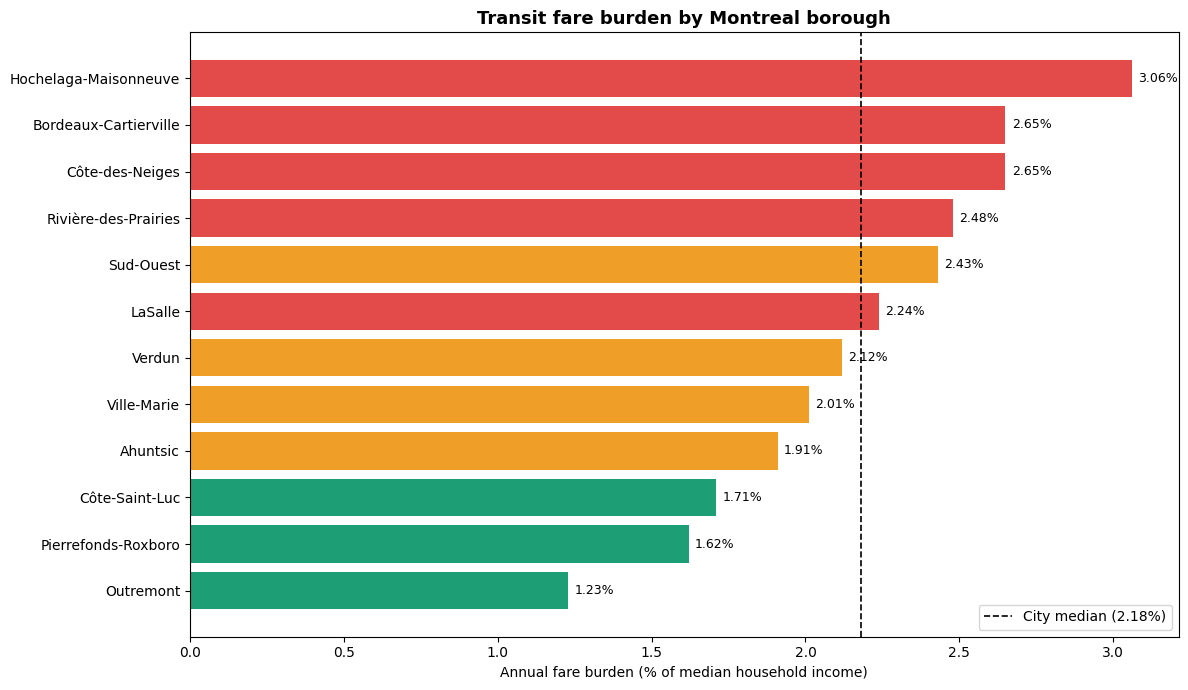

Chart 1 saved


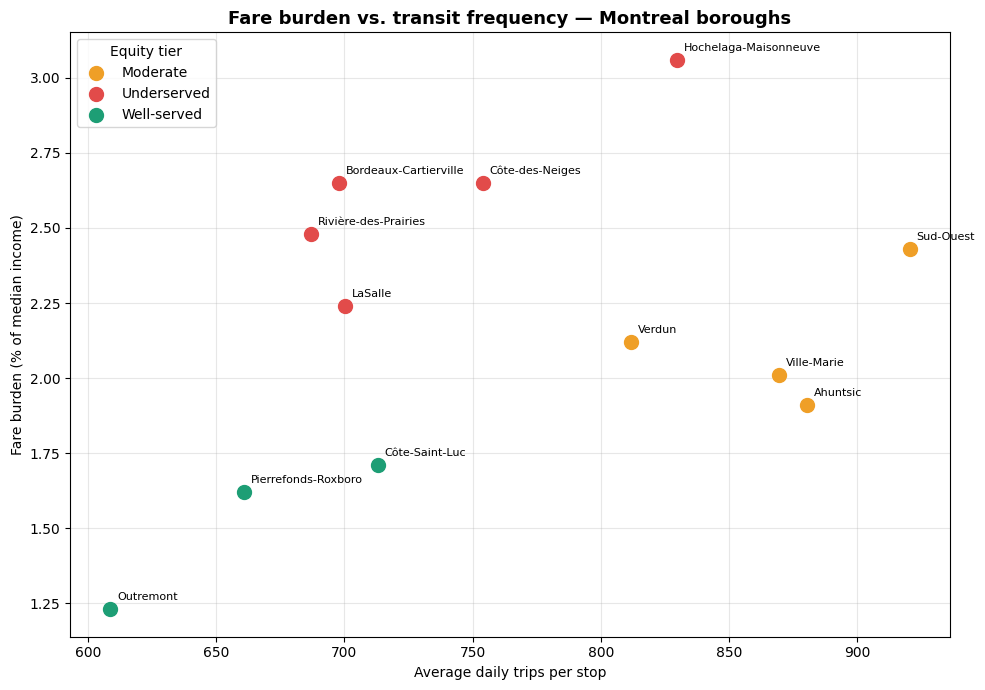

Chart 2 saved


In [10]:
# Assign meaningful labels based on cluster averages
label_map = {2: 'Underserved', 0: 'Moderate', 1: 'Well-served'}
borough_data['equity_label'] = borough_data['cluster'].map(label_map)

color_map = {
    'Underserved':  '#E24B4A',
    'Moderate':     '#EF9F27',
    'Well-served':  '#1D9E75'
}

# --- Chart 1: Fare burden by borough ---
fig, ax = plt.subplots(figsize=(12, 7))
sorted_data = borough_data.sort_values('fare_burden_pct')
colors = sorted_data['equity_label'].map(color_map)

ax.barh(sorted_data['borough'], sorted_data['fare_burden_pct'], color=colors)
ax.axvline(city_median, color='black', linestyle='--', linewidth=1.2, label=f'City median ({city_median:.2f}%)')

# Add value labels on each bar
for i, (val, label) in enumerate(zip(sorted_data['fare_burden_pct'], sorted_data['equity_label'])):
    ax.text(val + 0.02, i, f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Annual fare burden (% of median household income)')
ax.set_title('Transit fare burden by Montreal borough', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/fare_burden_chart.png', dpi=150)
plt.show()
print("Chart 1 saved")

# --- Chart 2: Scatter — burden vs frequency ---
fig, ax = plt.subplots(figsize=(10, 7))

for label, group in borough_data.groupby('equity_label'):
    ax.scatter(group['avg_daily_trips'], group['fare_burden_pct'],
               label=label, color=color_map[label], s=100, zorder=3)

for _, row in borough_data.iterrows():
    ax.annotate(row['borough'],
                (row['avg_daily_trips'], row['fare_burden_pct']),
                fontsize=8, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Average daily trips per stop')
ax.set_ylabel('Fare burden (% of median income)')
ax.set_title('Fare burden vs. transit frequency — Montreal boroughs', fontsize=13, fontweight='bold')
ax.legend(title='Equity tier')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/scatter_chart.png', dpi=150)
plt.show()
print("Chart 2 saved")

In [11]:
# Export to Excel for Power BI
borough_data.to_excel('../output/final_data.xlsx', index=False)

# Summary statistics
highest = borough_data.iloc[0]
lowest = borough_data.iloc[-1]
underserved = borough_data[borough_data['equity_label'] == 'Underserved']

print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)

print(f"\nBoroughs analyzed: {len(borough_data)}")
print(f"City median fare burden: {city_median:.2f}%")
print(f"\nHighest burden: {highest['borough']} — {highest['fare_burden_pct']}% of median income")
print(f"Lowest burden:  {lowest['borough']} — {lowest['fare_burden_pct']}% of median income")
print(f"Burden gap:     {(highest['fare_burden_pct'] / lowest['fare_burden_pct']):.1f}x between highest and lowest borough")

print(f"\nUnderserved boroughs ({len(underserved)}):")
for _, row in underserved.iterrows():
    print(f"  {row['borough']}: {row['fare_burden_pct']}% fare burden, {row['avg_daily_trips']} avg daily trips/stop")

print(f"\nClustering silhouette score: 0.499")
print(f"\nData exported to output/final_data.xlsx")

ANALYSIS SUMMARY

Boroughs analyzed: 12
City median fare burden: 2.18%

Highest burden: Hochelaga-Maisonneuve — 3.06% of median income
Lowest burden:  Outremont — 1.23% of median income
Burden gap:     2.5x between highest and lowest borough

Underserved boroughs (5):
  Hochelaga-Maisonneuve: 3.06% fare burden, 829.5 avg daily trips/stop
  Côte-des-Neiges: 2.65% fare burden, 753.9 avg daily trips/stop
  Bordeaux-Cartierville: 2.65% fare burden, 697.9 avg daily trips/stop
  Rivière-des-Prairies: 2.48% fare burden, 687.1 avg daily trips/stop
  LaSalle: 2.24% fare burden, 700.1 avg daily trips/stop

Clustering silhouette score: 0.499

Data exported to output/final_data.xlsx
